In [2]:
import os
import glob
import json
import pandas as pd
import numpy as np
import pandas as pd
import scipy.signal as sig
import scipy.ndimage as ndi
import stackview as st
import networkx as nx
import matplotlib.pyplot as plt
import skimage as ski
import iplotx as ipx

from copy import copy
from tifffile import imread

from pyfibre.fibers.metrics import fibre_network_metrics
from pyfibre.fibers.metrics import fibre_metrics
from pyfibre.fibers.network_extraction import fibre_network_assignment
from pyfibre.fibers.analysis import network_analysis
from pyfibre.fibers.fibre_network import FibreNetwork

In [5]:
example_dir = "/home/vpc/Pictures/Exemplo_Picro/"
#example_dir = 'C:/Users/User/Victor/Projetos/Picro_Lu/Stroma/21d-3/'
#example_output_dir = os.path.join(example_dir, 'Saída')

#os.makedirs(example_output_dir, exist_ok=True)
stack_path = os.path.join(example_dir, 'stack.tif')

#stack_path = os.path.join(example_dir, '21d-3_MMStack_Pos0.ome.tif')

stack = imread(stack_path)
pol= stack[5]
#pol = stack[2]

# Pre-processing

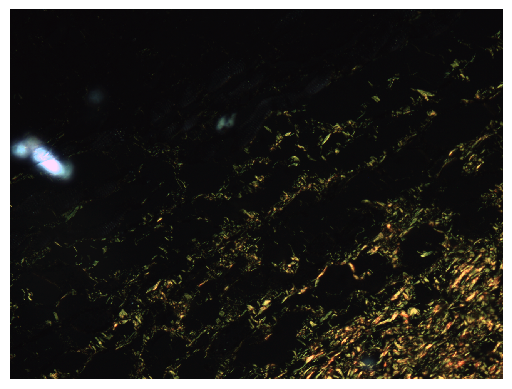

In [15]:
st.imshow(pol)

In [6]:
from pyfibre.tools.filters import tubeness, hysteresis
from pyfibre.utilities import clear_border
from pyfibre.tools.preprocessing import clip_intensities, nl_means

In [7]:
pol_hsv = ski.color.rgb2hsv(pol)
pol_val = pol_hsv[..., 2]
pol_hue = pol_hsv[..., 0]
pol_sat = pol_hsv[..., 1]

In [33]:
SIGMA = 2
p1 = 0
p2 = 0.4

hue_inv = ski.exposure.rescale_intensity(
    ndi.gaussian_filter(pol_hue, sigma=SIGMA), in_range=(p1,p2)
)

hue_thresh = ski.filters.threshold_otsu(hue_inv)
hue_mask = ski.morphology.remove_small_objects(hue_inv < hue_thresh)

In [36]:
pol_val_corr = pol_val * (hue_mask)
pol_val_sigma = ski.restoration.estimate_sigma(pol_val_corr)

In [37]:
DENOISE_PARAMS = {
    "patch_size": 5,
    "patch_distance": 12,
    "fast_mode": True,
    "sigma": pol_val_sigma
}

In [38]:
pol_val_dn = ski.restoration.denoise_nl_means(
    ski.exposure.equalize_adapthist(
        clip_intensities(
            pol_val_corr
        )
    ), **DENOISE_PARAMS
)

In [21]:
st.blend(pol_val, pol_val_dn, zoom_factor=0.25)

In [42]:
SIGMA=1
SCALE=0.5

pol_r = ski.transform.rescale(
    pol_val_dn,
    SCALE,
    mode='constant',
    anti_aliasing=None
)

SIGMA *= SCALE

In [48]:
pol_tb = ski.filters.sato(
    pol_r,
    sigmas=range(1,5),
    black_ridges=False,
    mode='constant'
)

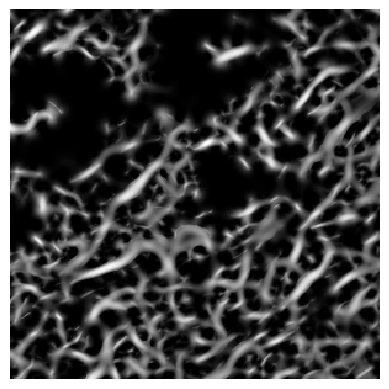

In [49]:
st.imshow(pol_tb[600:900, 900:1200])

In [50]:

pol_thresh = ski.morphology.remove_small_objects(
    hysteresis(pol_tb, alpha=0.5), max_size=32
)

pol_edt = ndi.distance_transform_edt(
    pol_thresh
)

# Nucleation points

In [54]:
NUC_RADIUS=20
NUC_THRESH = 2 # Because distance transform has weird values
R_THRESH = 10
FILT_RAD = R_THRESH // 2
SHAPE = pol_distance.shape

In [55]:
peak_coords = ski.feature.peak_local_max(
    pol_distance,
    labels=pol_thresh,
    threshold_abs=NUC_THRESH,
    min_distance=R_THRESH,
    footprint=np.ones((NUC_RADIUS, NUC_RADIUS)),
    exclude_border=10
)

nuc_y, nuc_x = peak_coords[:, 0], peak_coords[:, 1]

maxima = np.zeros_like(pol_distance)
maxima[nuc_y, nuc_x] = 1
n_nuc = len(peak_coords)
print(n_nuc)

1688


In [ ]:
nuc_graph = nx.Graph()

pos = {}

for i in range(n_nuc):
    coord_xy = np.array([
        nuc_x[i], nuc_y[i]
    ])
    coord_yx = peak_coords[i]

    pos[i] = coord

    nuc_graph.add_node(i, pos=coord_xy, index=i)

    filtered = ski.morphology.local_maxima(
        pol_distance * ring(coord_yx, SHAPE, FILT_RAD)
    )

    branch_coords = np.argwhere(filtered * pol_distance >= NUC_THRESH)

    n_branch = len(branch_coords)

    branch_y, branch_x = branch_coords[:, 0], branch_coords[:, 1]

    branch_vecs = np.tile(test, (n_branch, 1)) - branch_coords

    branch_r = np.sqrt(
        np.sum(branch_vecs**2, axis=1)
    )

    grown_nodes = n_nuc + np.arange(n_branch)

    for j in range(n_branch):   
        grown_idx = int(grown_nodes[j]) # so that dict isn't all weird

        grown_coord = np.array([
            branch_x[j], branch_y[j]
        ])

        pos[grown_idx] = grown_coord

        grown_r = branch_r[j]
        grown_vec = branch_vecs[j]
        grown_direction = -grown_vec / grown_r

        nuc_graph.add_node(
            grown_idx,
            pos=grown_coord,
            nuc=i,
            direction=grown_direction
            index=grown_idx
        )

        nuc_graph.add_edges_from(
            (i, idx),
            r=grown_r,
        )

nx.apply_matplotlib_colors(
    nuc_graph, "index", "color", plt.colormaps.get_cmap('prism')
)

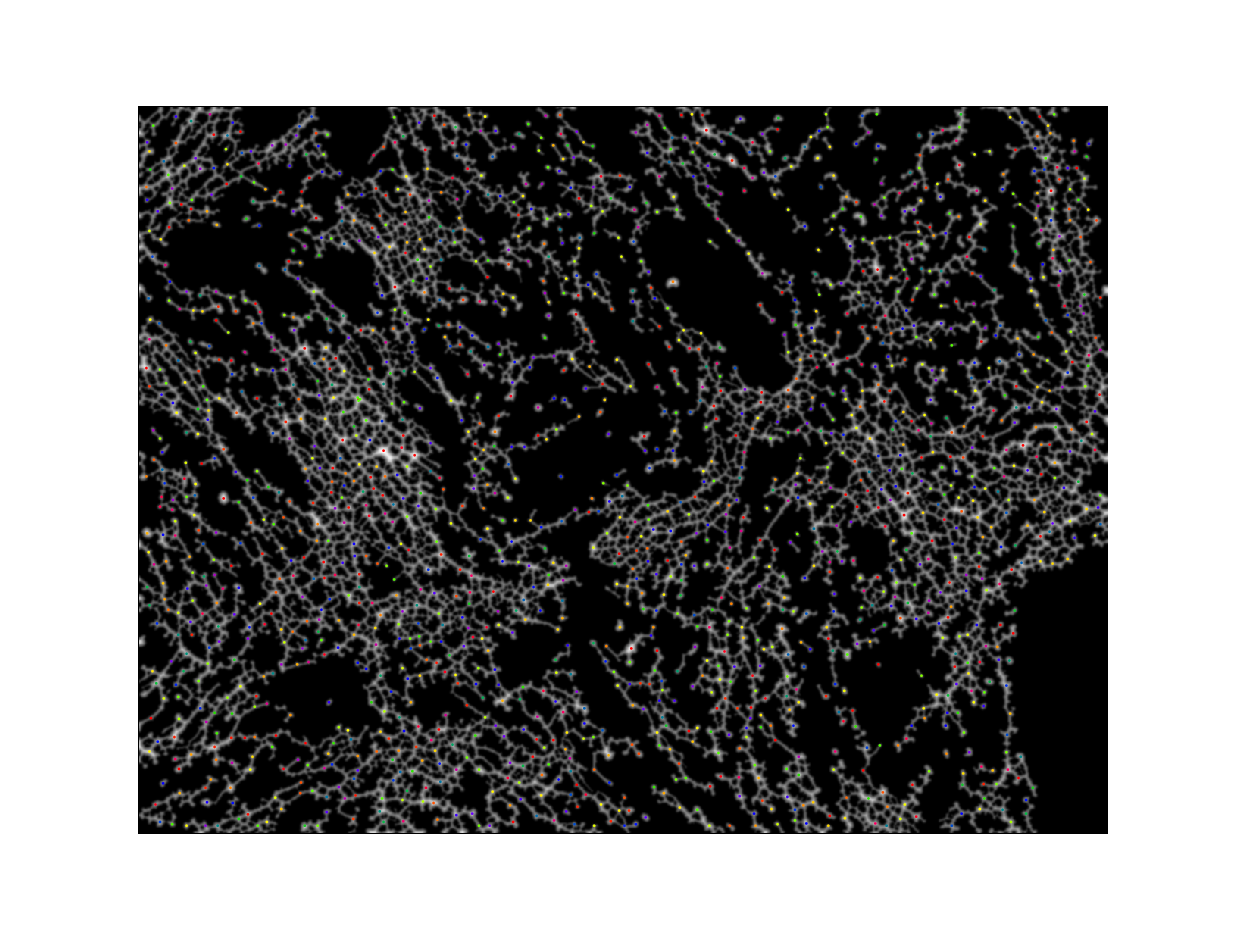

In [160]:
f, a = plt.subplots()
st.imshow(pol_distance, axes=a, continue_drawing=True)

style = {
    "vertex": {
        "facecolor": nuc_graph.nodes.data("color"),
        "size": 1
    }
}

ipx.network(
    nuc_graph,
    layout=pos,
    style=style,
    ax=a
)

f.set_dpi(200)
f.tight_layout()

In [58]:
# New ring filter !!!!

def ring(
    coords: np.typing.NDArray,
    shape: tuple,
    size: int=10
    ):
    """
    Generate a shape-shaped mask with a square ring of
    length size around a pixel coordinate
    """

    filt = np.zeros(shape).astype(np.float32)

    filt[*coords] = 1

    strel = np.ones((size, size))
    strel[1:size-1, 1:size-1] = 0

    filt = ndi.convolve(
        filt,
        strel,
        mode='constant',
    )

    return filt

In [ ]:

nx.apply_matplotlib_colors(
    nuc_graph, "index", "color", plt.colormaps.get_cmap('prism')
)

TypeError: Graph.add_edges_from() takes 2 positional arguments but 3 were given